# Plot Tendency Correlations

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from graphcast.model_utils import dataset_to_stacked

In [2]:
def plot_correlation(ax,
                     da: xr.DataArray,
                     ticks: tuple = (0, 1, 8, 15, 22, 29),
                     ticklabels: tuple = ("ssh", "so", "temp", "uo", "vo"),
                     title: str = None,
                     cmap: str = "RdBu_r",
                     vmin: float = None,
                     vmax: float = None,
                     add_colorbar: bool = False,
                    ):
    """A manuscript-ready correlation plot component."""
    # Plot the heatmap
    p = da.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=add_colorbar)

    # Draw separator lines
    for tick_pos in ticks[1:]:
        line_pos = tick_pos - 0.5
        ax.axvline(line_pos, color='gray', linestyle=':', linewidth=1.5)
        ax.axhline(line_pos, color='gray', linestyle=':', linewidth=1.5)

    # Clean up default axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Add custom axis labels
    for i in range(len(ticks) - 1):
        start, end = ticks[i], ticks[i+1]
        midpoint = (start + end - 1) / 2
        label = ticklabels[i].upper() # Use uppercase for clarity

        ax.text(-0.07, midpoint, label, ha='center', va='center', rotation='vertical',
                fontsize=10, transform=ax.get_yaxis_transform(), clip_on=False)
        ax.text(midpoint, -0.07, label, ha='center', va='center',
                fontsize=10, transform=ax.get_xaxis_transform(), clip_on=False)

    if title is not None:
        ax.set_title(title, fontsize=12, pad=10)
    
    return p

In [3]:
# ---- Reference Truth Tendency Correlations ----
# File location and name 
loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only/tendency_correlations"
fname = "tendency_correlation_ocn_only_24h_rm_seasonality.nc"

# open file
f = xr.open_dataset(os.path.join(loc, fname))
corr_tend_replay = f.targets

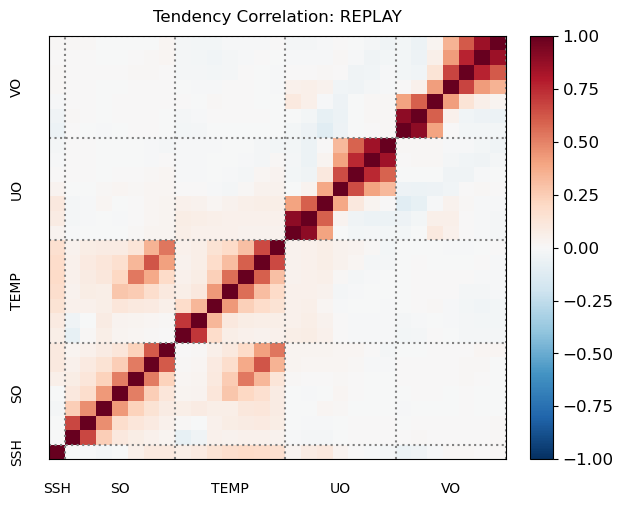

In [4]:
save_plot = True

# Global Settings for a Professional Look
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': 'DejaVu Sans', 'font.size': 12})

# Setup the Figure and GridSpec Layout
nrows, ncols = 1, 1
fig = plt.figure(figsize=(6.5 * ncols, 5.5 * nrows))

# Create a grid: 1 plot columns, 1 thin colorbar column per row
# hspace increases vertical space between rows
gs = gridspec.GridSpec(nrows, ncols + 1, figure=fig, 
                       width_ratios=[1, 0.05], 
                       wspace=0.1, hspace=0.35)

# Create Axes
axes = [fig.add_subplot(gs[i, j]) for i in range(nrows) for j in range(ncols)]
cax1 = fig.add_subplot(gs[0, 1]) # Colorbar axis for top row

# Plot Data
p1 = plot_correlation(axes[0], corr_tend_replay, title="Tendency Correlation: REPLAY")

# Add Shared Colorbars
fig.colorbar(p1, cax=cax1)

if save_plot:
    plt.savefig("./figures/figure1.png", dpi=300)

plt.show()